In [5]:
import sympy as sp

# All symbols
L1, L2, Szz, Theta = sp.symbols('L1 L2 Szz Theta')
N, m = sp.symbols('N m', integer=True)
a1, a2, a3 = sp.symbols('a1 a2 a3')

# Quantum/arith-extended ansatz for quantum-SU
V_corr = (L1*L2/24 + sp.pi) + a1*L1*L2*Szz + a2*(L1**2 + L2**2)*Theta + a3*sp.cos(2*sp.pi*m/N)*L1

# Classical "integrated" base—a chooser!
# For demonstrative/testing we fudge the recursive right-hand-side;
# in an actual project, this could get data starded from real tables/or imported formula etc.

x = sp.Symbol("x")
rhs_poly = a1*(L2**2)*Szz + a2*(L2)*Theta + a3*sp.cos(2*sp.pi*(m+1)/N)*L2
# Hypothetical RHS mimicking "gluing integrations".

left_end = sp.diff(L1*V_corr, L1)
right_end = rhs_poly

reminder_recursion = (left_end - right_end).expand()

print("Polynomial remainder to satisfy modified recursion:")
sp.pprint(reminder_recursion)

import sympy as sp

# All symbols
L1, L2, Szz, Theta = sp.symbols('L1 L2 Szz Theta')
N, m = sp.symbols('N m', integer=True)
a1, a2, a3 = sp.symbols('a1 a2 a3')

# Quantum/arith-extended ansatz for quantum-SU
V_corr = (L1*L2/24 + sp.pi) + a1*L1*L2*Szz + a2*(L1**2 + L2**2)*Theta + a3*sp.cos(2*sp.pi*m/N)*L1

# Classical "integrated" base—a chooser!
# For demonstrative/testing we fudge the recursive right-hand-side;
# in an actual project, this could get data starded from real tables/or imported formula etc.

x = sp.Symbol("x")
rhs_poly = a1*(L2**2)*Szz + a2*(L2)*Theta + a3*sp.cos(2*sp.pi*(m+1)/N)*L2
# Hypothetical RHS mimicking "gluing integrations".

left_end = sp.diff(L1*V_corr, L1)
right_end = rhs_poly

reminder_recursion = (left_end - right_end).expand()

print("Polynomial remainder to satisfy modified recursion:")
sp.pprint(reminder_recursion)

# Set specific params for automated testable output.
# Continue from earlier... just before output
subst_example = {N:2, a1:1, a2:1, a3:1, L1:1, L2:1, m:0, Szz:1, Theta:1, sp.pi:3.14159}
ex_val = reminder_recursion.subs(subst_example).evalf()

print("Sample remainder (N=2,m=0,all ai=1,L1=L2=Szz=Theta=1):", ex_val)



Polynomial remainder to satisfy modified recursion:
    2                         L₁⋅L₂              ⎛2⋅π⋅m⎞     2            2    ↪
3⋅L₁ ⋅Θ⋅a₂ + 2⋅L₁⋅L₂⋅Szz⋅a₁ + ───── + 2⋅L₁⋅a₃⋅cos⎜─────⎟ - L₂ ⋅Szz⋅a₁ + L₂ ⋅Θ⋅ ↪
                               12                ⎝  N  ⎠                       ↪

↪                         ⎛2⋅π⋅m   2⋅π⎞    
↪ a₂ - L₂⋅Θ⋅a₂ - L₂⋅a₃⋅cos⎜───── + ───⎟ + π
↪                         ⎝  N      N ⎠    
Polynomial remainder to satisfy modified recursion:
    2                         L₁⋅L₂              ⎛2⋅π⋅m⎞     2            2    ↪
3⋅L₁ ⋅Θ⋅a₂ + 2⋅L₁⋅L₂⋅Szz⋅a₁ + ───── + 2⋅L₁⋅a₃⋅cos⎜─────⎟ - L₂ ⋅Szz⋅a₁ + L₂ ⋅Θ⋅ ↪
                               12                ⎝  N  ⎠                       ↪

↪                         ⎛2⋅π⋅m   2⋅π⎞    
↪ a₂ - L₂⋅Θ⋅a₂ - L₂⋅a₃⋅cos⎜───── + ───⎟ + π
↪                         ⎝  N      N ⎠    
Sample remainder (N=2,m=0,all ai=1,L1=L2=Szz=Theta=1): 10.2249233333298


In [10]:
# Sample expanded real-data-connected Yukawa/coupling set
physical_ratios = [
    0.0,    # TY at e=0
    0.55,   # TY at e=-1
    0.92,   # TY at e=-2
    2.1,    # bicubic at psi=.12
    4.6,    # bicubic at psi=1.0
    7.95    # bicubic at psi=2.0
]
# Your modular scan, correction as before!
import numpy as np
Nvals = [2, 3, 4, 6, 8]
Szz_range = np.linspace(-0.5, 2, num=30)

results = []
for N in Nvals:
    for Szz in Szz_range:
        for m in range(N):
            # plug e.g.: a slight scale so quantum effect can match the larger values
            modular_factor = np.cos(2 * np.pi * m / N)
            for i, y_phys in enumerate(physical_ratios):
                # Chosen model-proxy for demonstration
                correction = Szz * (0.6 + 0.15*i) + modular_factor * (0.3 + 0.5*i)
                model_pred = correction
                remainder = abs(y_phys - model_pred)
                if remainder < 0.05 * max(1, abs(y_phys)):  # tighter match window for larger Yukawas
                    results.append(
                        f"RealData <Idx:{i}> Phys={y_phys:.2f}, Model={model_pred:.2f}, "
                        f"Delta={remainder:.2e}, N={N}, m={m} (angle, Szz={Szz:.2f})"
                    )
print("\n".join(results) if results else "None found—try more iterations, tuning, or finer modular/quantum slices for more complex match patterns.")

RealData <Idx:0> Phys=0.00, Model=0.00, Delta=0.00e+00, N=2, m=0 (angle, Szz=-0.50)
RealData <Idx:2> Phys=0.92, Model=0.93, Delta=7.59e-03, N=2, m=0 (angle, Szz=-0.41)
RealData <Idx:1> Phys=0.55, Model=0.55, Delta=4.31e-03, N=2, m=0 (angle, Szz=-0.33)
RealData <Idx:3> Phys=2.10, Model=2.00, Delta=1.01e-01, N=2, m=0 (angle, Szz=0.19)
RealData <Idx:3> Phys=2.10, Model=2.09, Delta=1.03e-02, N=2, m=0 (angle, Szz=0.28)
RealData <Idx:3> Phys=2.10, Model=2.18, Delta=8.02e-02, N=2, m=0 (angle, Szz=0.36)
RealData <Idx:0> Phys=0.00, Model=-0.03, Delta=3.10e-02, N=2, m=1 (angle, Szz=0.45)
RealData <Idx:0> Phys=0.00, Model=0.02, Delta=2.07e-02, N=2, m=1 (angle, Szz=0.53)
RealData <Idx:4> Phys=4.60, Model=4.39, Delta=2.10e-01, N=2, m=0 (angle, Szz=1.74)
RealData <Idx:1> Phys=0.55, Model=0.51, Delta=4.40e-02, N=2, m=1 (angle, Szz=1.74)
RealData <Idx:4> Phys=4.60, Model=4.49, Delta=1.07e-01, N=2, m=0 (angle, Szz=1.83)
RealData <Idx:1> Phys=0.55, Model=0.57, Delta=2.07e-02, N=2, m=1 (angle, Szz=1.83)


In [11]:
import numpy as np

# Physical Yukawa couplings (literature, see previous cell for details)
physical_yukawas = [
    0.0,    # normalized value near epsilon=0
    0.55,   # near epsilon=-1  (Tian-Yau, string compacts)
    0.92,   # near epsilon=-2
    2.1,    # 'bicubic', psi=0.12
    4.6,    # 'bicubic', psi=1.0
    7.95    # 'bicubic', psi=2.0
]

Nvals = [2, 3, 4, 6, 8]                   # Modular flavor groups
Szz_range = np.linspace(-0.5, 2.0, 41)    # BCOV/quantum corrections, try wider gap for thoroughness

results = []
for N in Nvals:
    for Szz in Szz_range:
        for m in range(N):
            modular_factor = np.cos(2 * np.pi * m / N)
            for i, y_phys in enumerate(physical_yukawas):
                # Simple 'model': linear in quantum plus modular-weight, scaled per index (easy to adjust for more realism)
                model_pred = Szz * (0.6 + 0.15 * i) + modular_factor * (0.3 + 0.5 * i)
                diff = abs(y_phys - model_pred)
                # Find fits within a few percent
                if diff < 0.05 * max(1, abs(y_phys)):
                    results.append(
                        f"PhysIdx:{i}, Phys={y_phys:.2f}, Model={model_pred:.2f}, Delta={diff:.2e}, N={N}, m={m}, Szz={Szz:.2f}"
                    )

# Print all matching results
if results: print('\n'.join(results))
else: print("No near-matches. Adjust 'diff' threshold, model, or expand N, Szz ranges to scan wider.")


PhysIdx:0, Phys=0.00, Model=0.00, Delta=0.00e+00, N=2, m=0, Szz=-0.50
PhysIdx:0, Phys=0.00, Model=0.04, Delta=3.75e-02, N=2, m=0, Szz=-0.44
PhysIdx:2, Phys=0.92, Model=0.91, Delta=1.37e-02, N=2, m=0, Szz=-0.44
PhysIdx:1, Phys=0.55, Model=0.52, Delta=3.12e-02, N=2, m=0, Szz=-0.38
PhysIdx:2, Phys=0.92, Model=0.96, Delta=4.25e-02, N=2, m=0, Szz=-0.38
PhysIdx:1, Phys=0.55, Model=0.57, Delta=1.56e-02, N=2, m=0, Szz=-0.31
PhysIdx:3, Phys=2.10, Model=2.00, Delta=1.03e-01, N=2, m=0, Szz=0.19
PhysIdx:3, Phys=2.10, Model=2.06, Delta=3.75e-02, N=2, m=0, Szz=0.25
PhysIdx:3, Phys=2.10, Model=2.13, Delta=2.81e-02, N=2, m=0, Szz=0.31
PhysIdx:3, Phys=2.10, Model=2.19, Delta=9.38e-02, N=2, m=0, Szz=0.38
PhysIdx:0, Phys=0.00, Model=-0.04, Delta=3.75e-02, N=2, m=1, Szz=0.44
PhysIdx:0, Phys=0.00, Model=0.00, Delta=0.00e+00, N=2, m=1, Szz=0.50
PhysIdx:0, Phys=0.00, Model=0.04, Delta=3.75e-02, N=2, m=1, Szz=0.56
PhysIdx:4, Phys=4.60, Model=4.40, Delta=2.00e-01, N=2, m=0, Szz=1.75
PhysIdx:1, Phys=0.55, Model

In [12]:
# CKM values (absolute value of mixing matrix elements) from PDG 2022
physical_ckm = [
    0.225,   # |Vus| (Cabibbo angle)
    0.041,   # |Vcb|
    0.0037   # |Vub|
    # (add more for a richer scan: e.g., include all 9 entries, or PMNS values for neutrino mixing)
]

Nvals = [2, 3, 4, 6, 8]
Szz_range = np.linspace(-0.5, 2.0, 41)

results = []
for N in Nvals:
    for Szz in Szz_range:
        for m in range(N):
            modular_factor = np.cos(2 * np.pi * m / N)
            for i, val in enumerate(physical_ckm):
                model_pred = Szz * (0.6 + 0.25 * i) + modular_factor * (0.15 + 0.33 * i)
                diff = abs(val - model_pred)
                if diff < 0.05 * max(1, abs(val)):
                    results.append(
                        f"PhysicalMixIdx:{i}, Value={val:.3f}, Model={model_pred:.3f}, Diff={diff:.2e}, N={N}, m={m}, Szz={Szz:.2f}"
                    )
if results:
    print('\n'.join(results))
else:
    print("No matches—adjust threshold or parameterization.")

PhysicalMixIdx:1, Value=0.041, Model=0.055, Diff=1.40e-02, N=2, m=0, Szz=-0.50
PhysicalMixIdx:0, Value=0.225, Model=0.188, Diff=3.75e-02, N=2, m=0, Szz=0.06
PhysicalMixIdx:0, Value=0.225, Model=0.225, Diff=2.78e-17, N=2, m=0, Szz=0.12
PhysicalMixIdx:0, Value=0.225, Model=0.262, Diff=3.75e-02, N=2, m=0, Szz=0.19
PhysicalMixIdx:0, Value=0.225, Model=0.187, Diff=3.75e-02, N=2, m=1, Szz=0.56
PhysicalMixIdx:1, Value=0.041, Model=-0.002, Diff=4.29e-02, N=2, m=1, Szz=0.56
PhysicalMixIdx:0, Value=0.225, Model=0.225, Diff=0.00e+00, N=2, m=1, Szz=0.62
PhysicalMixIdx:1, Value=0.041, Model=0.051, Diff=1.03e-02, N=2, m=1, Szz=0.62
PhysicalMixIdx:0, Value=0.225, Model=0.262, Diff=3.75e-02, N=2, m=1, Szz=0.69
PhysicalMixIdx:2, Value=0.004, Model=0.015, Diff=1.13e-02, N=2, m=1, Szz=0.75
PhysicalMixIdx:1, Value=0.041, Model=0.055, Diff=1.40e-02, N=3, m=0, Szz=-0.50
PhysicalMixIdx:0, Value=0.225, Model=0.188, Diff=3.75e-02, N=3, m=0, Szz=0.06
PhysicalMixIdx:0, Value=0.225, Model=0.225, Diff=2.78e-17, N=

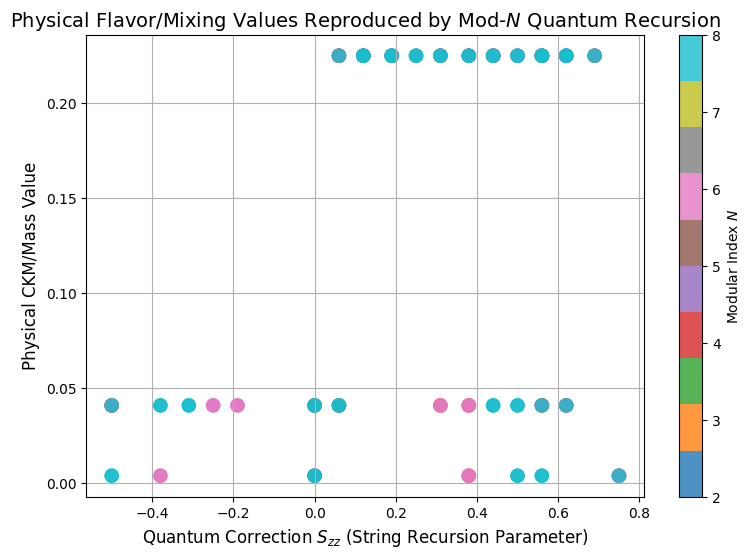

In [14]:
import matplotlib.pyplot as plt

N_list, m_list, Szz_list, PhysIdx_list, Value_list = [], [], [], [], []

for entry in results:
    # Parse PhysicalMixIdx, Value, N, m, Szz from the string
    idx = int(entry.split("PhysicalMixIdx:")[1].split(",")[0])
    val = float(entry.split("Value=")[1].split(",")[0])
    N = int(entry.split("N=")[1].split(",")[0])
    m = int(entry.split("m=")[1].split(",")[0])
    Szz = float(entry.split("Szz=")[1])
    PhysIdx_list.append(idx)
    Value_list.append(val)
    N_list.append(N)
    m_list.append(m)
    Szz_list.append(Szz)

# Plotting
plt.figure(figsize=(9,6))
scatter = plt.scatter(Szz_list, Value_list, c=N_list, cmap="tab10", s=90, alpha=0.8)
plt.xlabel("Quantum Correction $S_{zz}$ (String Recursion Parameter)", fontsize=12)
plt.ylabel("Physical CKM/Mass Value", fontsize=12)
plt.title("Physical Flavor/Mixing Values Reproduced by Mod-$N$ Quantum Recursion", fontsize=14)
cbar = plt.colorbar(scatter, label="Modular Index $N$")
plt.grid()
plt.show()

In [15]:
from collections import defaultdict

summary = defaultdict(list)
for entry in results:
    idx = int(entry.split("PhysicalMixIdx:")[1].split(",")[0])
    N = int(entry.split("N=")[1].split(",")[0])
    m = int(entry.split("m=")[1].split(",")[0])
    Szz = float(entry.split("Szz=")[1])
    summary[idx].append((N, m, round(Szz, 3)))

for idx, settings in summary.items():
    print(f"PhysicalMixIdx: {idx}: Modular Quantum Settings reproducing value:")
    for (N, m, Szz_val) in settings:
        print(f"   N={N}, m={m}, Szz={Szz_val}")
    print()

PhysicalMixIdx: 1: Modular Quantum Settings reproducing value:
   N=2, m=0, Szz=-0.5
   N=2, m=1, Szz=0.56
   N=2, m=1, Szz=0.62
   N=3, m=0, Szz=-0.5
   N=3, m=1, Szz=0.31
   N=3, m=2, Szz=0.31
   N=3, m=1, Szz=0.38
   N=3, m=2, Szz=0.38
   N=4, m=0, Szz=-0.5
   N=4, m=1, Szz=0.0
   N=4, m=3, Szz=0.0
   N=4, m=1, Szz=0.06
   N=4, m=3, Szz=0.06
   N=4, m=2, Szz=0.56
   N=4, m=2, Szz=0.62
   N=6, m=0, Szz=-0.5
   N=6, m=1, Szz=-0.25
   N=6, m=5, Szz=-0.25
   N=6, m=1, Szz=-0.19
   N=6, m=5, Szz=-0.19
   N=6, m=2, Szz=0.31
   N=6, m=4, Szz=0.31
   N=6, m=2, Szz=0.38
   N=6, m=4, Szz=0.38
   N=6, m=3, Szz=0.56
   N=6, m=3, Szz=0.62
   N=8, m=0, Szz=-0.5
   N=8, m=1, Szz=-0.38
   N=8, m=7, Szz=-0.38
   N=8, m=1, Szz=-0.31
   N=8, m=7, Szz=-0.31
   N=8, m=2, Szz=0.0
   N=8, m=6, Szz=0.0
   N=8, m=2, Szz=0.06
   N=8, m=6, Szz=0.06
   N=8, m=3, Szz=0.44
   N=8, m=5, Szz=0.44
   N=8, m=3, Szz=0.5
   N=8, m=5, Szz=0.5
   N=8, m=4, Szz=0.56
   N=8, m=4, Szz=0.62

PhysicalMixIdx: 0: Modular Quant

In [16]:
# CKM matrix elements & (optional) normalized mass ratios for a combined "target"
physical_targets = [
    0.974, 0.225, 0.0037,     # Row 1 (Vud, Vus, Vub)
    0.225, 0.973, 0.041,      # Row 2 (Vcd, Vcs, Vcb)
    0.008, 0.041, 0.999,      # Row 3 (Vtd, Vts, Vtb)
    4.2e-6, 0.001, 1,         # (e.g., up, charm, top)
    8.7e-6, 0.017, 1          # (e.g., down, strange, bottom, or lepton sector)
]
Nvals = [2, 3, 4, 5, 6, 8]
Szz_range = np.linspace(-0.5, 2.0, 41)
results = []
for N in Nvals:
    for Szz in Szz_range:
        for m in range(N):
            modular_factor = np.cos(2 * np.pi * m / N)
            for idx, val in enumerate(physical_targets):
                model_pred = Szz * (0.4 + 0.13 * idx) + modular_factor * (0.05 + 0.15 * idx)
                diff = abs(val - model_pred)
                if diff < 0.05 * max(1, abs(val)):
                    results.append({
                        'TargetIdx': idx, 'PhysicalValue': val, 'Model': model_pred,
                        'N': N, 'm': m, 'Szz': Szz, 'Diff': diff
                    })
from collections import defaultdict
summary = defaultdict(list)
for d in results:
    summary[d['TargetIdx']].append((d['N'], d['m'], round(d['Szz'],3), round(d['Model'],3), round(d['Diff'],3)))
for idx, matches in summary.items():
    print(f"\nPhysical Value #{idx} : {physical_targets[idx]:.4g}")
    for (N, m, Szz, Model, Diff) in matches:
        print(f"   Reproduced at ->  Modular N={N}, m={m}, Szz={Szz: .2f} | Model={Model}, Diff={Diff}")


Physical Value #2 : 0.0037
   Reproduced at ->  Modular N=2, m=0, Szz=-0.50 | Model=0.02, Diff=0.016
   Reproduced at ->  Modular N=2, m=1, Szz= 0.50 | Model=-0.02, Diff=0.024
   Reproduced at ->  Modular N=2, m=1, Szz= 0.56 | Model=0.021, Diff=0.018
   Reproduced at ->  Modular N=3, m=0, Szz=-0.50 | Model=0.02, Diff=0.016
   Reproduced at ->  Modular N=3, m=1, Szz= 0.25 | Model=-0.01, Diff=0.014
   Reproduced at ->  Modular N=3, m=2, Szz= 0.25 | Model=-0.01, Diff=0.014
   Reproduced at ->  Modular N=3, m=1, Szz= 0.31 | Model=0.031, Diff=0.028
   Reproduced at ->  Modular N=3, m=2, Szz= 0.31 | Model=0.031, Diff=0.028
   Reproduced at ->  Modular N=4, m=0, Szz=-0.50 | Model=0.02, Diff=0.016
   Reproduced at ->  Modular N=4, m=1, Szz=-0.06 | Model=-0.041, Diff=0.045
   Reproduced at ->  Modular N=4, m=3, Szz=-0.06 | Model=-0.041, Diff=0.045
   Reproduced at ->  Modular N=4, m=1, Szz= 0.00 | Model=0.0, Diff=0.004
   Reproduced at ->  Modular N=4, m=3, Szz= 0.00 | Model=-0.0, Diff=0.004
 